# Mini-Project 1

In [1]:
%gui wx
import sys
import os

#####################
# Import of utils.py functions
#####################
# Required to get utils.py and access its functions
notebook_dir = os.path.abspath("")
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.append(parent_dir)
sys.path.append('.')
from utils import loadFSL, FSLeyesServer, mkdir_no_exist, interactive_MCQ

####################
# DIPY_HOME should be set prior to import of dipy to make sure all downloads point to the right folder
####################
os.environ["DIPY_HOME"] = "/home/jovyan/Data"


#############################
# Loading fsl and freesurfer within Neurodesk
# You can find the list of available other modules by clicking on the "Softwares" tab on the left
#############################
import lmod
await lmod.purge(force=True)
await lmod.load('fsl/6.0.7.4')
await lmod.load('freesurfer/7.4.1')
await lmod.list()

####################
# Setup FSL path
####################
loadFSL()

###################
# Load all relevant libraries for the lab
##################
import fsl.wrappers
from fsl.wrappers import fslmaths

import mne_nirs
import nilearn
from nilearn.datasets import fetch_development_fmri

import mne
import mne_nirs
import dipy
from dipy.data import fetch_bundles_2_subjects, read_bundles_2_subjects
import xml.etree.ElementTree as ET
import os.path as op
import nibabel as nib
import glob

!pip install antspyx
import ants

import openneuro
from mne.datasets import sample
from mne_bids import BIDSPath, read_raw_bids, print_dir_tree, make_report


# Useful imports to define the direct download function below
import requests
import urllib.request
from tqdm import tqdm


# FSL function wrappers which we will call from python directly
from fsl.wrappers import fast, bet
from fsl.wrappers.misc import fslroi
from fsl.wrappers import flirt

# General purpose imports to handle paths, files etc
import glob
import pandas as pd
import numpy as np
import json

Gtk-Message: 17:53:22.542: Failed to load module "canberra-gtk-module"


## Usefull functions

In [2]:
class DownloadProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)

def download_url(url, output_path):
    with DownloadProgressBar(unit='B', unit_scale=True,
                             miniters=1, desc=url.split('/')[-1]) as t:
        urllib.request.urlretrieve(url, filename=output_path, reporthook=t.update_to)

def direct_file_download_open_neuro(file_list, file_types, dataset_id, dataset_version, save_dirs):
    # https://openneuro.org/crn/datasets/ds004226/snapshots/1.0.0/files/sub-001:sub-001_scans.tsv
    for i, n in enumerate(file_list):
        subject = n.split('_')[0]
        download_link = 'https://openneuro.org/crn/datasets/{}/snapshots/{}/files/{}:{}:{}'.format(dataset_id, dataset_version, subject, file_types[i],n)
        print('Attempting download from ', download_link)
        download_url(download_link, op.join(save_dirs[i], n))
        print('Ok')
        
def get_json_from_file(fname):
    f = open(fname)
    data = json.load(f)
    f.close()
    return data

In [3]:
###############
# Start FSLeyes (very neat tool to visualize MRI data of all sorts) within Python
################
loadFSL()
fsleyesDisplay = FSLeyesServer()
fsleyesDisplay.show()

17:53:55: Debug: Adding duplicate image handler for 'Windows bitmap file'
17:53:55: Debug: Adding duplicate animation handler for '1' type
17:53:55: Debug: Adding duplicate animation handler for '2' type
17:53:55: Debug: Adding duplicate image handler for 'Windows bitmap file'
17:53:55: Debug: Adding duplicate animation handler for '1' type
17:53:55: Debug: Adding duplicate animation handler for '2' type

(ipykernel_launcher.py:8736): Gtk-CRITICAL **: 17:53:55.825: gtk_window_resize: assertion 'height > 0' failed


# Visualization of the data in FSL

Take care of the path of the file! 

In [5]:
fsleyesDisplay.load(op.expandvars('/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/data/subject101410/T1w/T1w'))

In [ ]:
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(op.expandvars('/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/data/subject101410/fMRI/tfMRI_MOTOR_LR/tfMRI_MOTOR_LR'))

In [ ]:
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(op.expandvars('/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/data/fMRI/tfMRI_MOTOR_RL/tfMRI_MOTOR_RL'))

# Use BIDS standard

In [4]:
dataset_id = 'subject101410'
subject = '101410' 

sample_path = "/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/data"
mkdir_no_exist(sample_path)
bids_root = op.join(sample_path, dataset_id)
deriv_root = op.join(bids_root, 'derivatives')
preproc_root = op.join(bids_root, 'derivatives','preprocessed_data')

subject_dir = 'sub-{}'.format(subject)

anat_dir = op.join(bids_root,subject_dir,"anat")
func_dir = op.join(bids_root,subject_dir,"func")

#### TO RUN ONLY IF YOU DON'T HAVE THE STRUCTURE

In [7]:
mkdir_no_exist(bids_root)

###################
# Create folders relevant for preprocessing.
# In BIDs, ANYTHING we modify must go in the derivatives folder, to keep original files clean in case we make a mistake.
###################
mkdir_no_exist(op.join(bids_root, 'derivatives'))
preproc_root = op.join(bids_root, 'derivatives','preprocessed_data')
mkdir_no_exist(preproc_root)
mkdir_no_exist(op.join(preproc_root, 'sub-101410'))
mkdir_no_exist(op.join(preproc_root, 'sub-101410', 'anat'))
mkdir_no_exist(op.join(preproc_root, 'sub-101410', 'func'))
mkdir_no_exist(op.join(preproc_root, 'sub-101410', 'fmap'))

In [8]:
print_dir_tree(bids_root, max_depth=5)

|subject101410/
|--- derivatives/
|------ preprocessed_data/
|--------- sub-101410/
|------------ anat/
|------------ fmap/
|------------ func/
|--- sub-101410/
|------ anat/
|------ func/


#### Now, we have to place the files we have downloaded before in the good directories according to the BIDS standard
#### TO RUN ONLY IF YOU DON'T HAVE THE STRUCTURE

In [18]:
import shutil

# Create the anat and func folders
os.makedirs(anat_dir, exist_ok=True)
os.makedirs(func_dir, exist_ok=True)

anat_src = op.join(bids_root, "T1w", "T1w.nii.gz")
func_root = op.join(bids_root, "fMRI")

# Déplacer et renommer le T1w
anat_dest = op.join(anat_dir, f"sub-{subject}_T1w.nii.gz")
shutil.copy(anat_src, anat_dest)

# Gérer les deux runs fMRI (LR et RL)
fmri_tasks = {
    "tfMRI_MOTOR_LR": "motorLR",
    "tfMRI_MOTOR_RL": "motorRL"
}

for folder, task_name in fmri_tasks.items():
    func_path = op.join(func_root, folder)
    bold_src = op.join(func_path, f"{folder}.nii")
    events_src = op.join(func_path, f"events_{folder.split('_')[-1]}.csv")

    bold_dest = op.join(func_dir, f"sub-{subject}_task-{task_name}_bold.nii")
    events_dest = op.join(func_dir, f"sub-{subject}_task-{task_name}_events.tsv")

    shutil.copy(bold_src, bold_dest)
    shutil.copy(events_src, events_dest)

In [19]:
print_dir_tree(bids_root, max_depth=4)

|subject101410/
|--- T1w/
|------ T1w.nii.gz
|--- derivatives/
|------ preprocessed_data/
|--------- sub-101410/
|------------ anat/
|------------ fmap/
|------------ func/
|--- fMRI/
|------ tfMRI_MOTOR_LR/
|--------- events_LR.csv
|--------- tfMRI_MOTOR_LR.nii
|------ tfMRI_MOTOR_RL/
|--------- events_RL.csv
|--------- tfMRI_MOTOR_RL.nii
|--- sub-101410/
|------ anat/
|--------- sub-101410_T1w.nii.gz
|------ func/
|--------- sub-101410_task-motorLR_bold.nii
|--------- sub-101410_task-motorLR_events.tsv
|--------- sub-101410_task-motorRL_bold.nii
|--------- sub-101410_task-motorRL_events.tsv


#### Nice! All the files are at the right place with the right name (we don't need the T1w and fMRI folders anymore)

# 1. Structural preprocessing

## Skull-Stripping

In [ ]:
def get_skull_stripped_anatomical(bids_root, preproc_root, subject_id, robust=False):
    """
    Function to perform skull-stripping (removing the skull around the brain).
    This is a simple wrapper around the brain extraction tool (BET) in FSL's suite
    It assumes data to be in the BIDS format (which we will cover in the following weeks).
    The method also saves the brain mask which was used to extract the brain.

    The brain extraction is conducted only on the T1w of the participant.

    Parameters
    ----------
    bids_root: string
        The root of the BIDS directory
    preproc_root: string
        The root of the preprocessed data, where the result of the brain extraction will be saved.
    subject_id: string
        Subject ID, the subject on which brain extraction should be conducted.
    robust: bool
        Whether to conduct robust center estimation with BET or not. Default is False.
    """
    # We perform here skull stripping (you'll learn more about it next week!).
    # For now all you need to do is that we remove the bones and flesh from the MRI to get the brain!
    subject = 'sub-{}'.format(subject_id)
    anatomical_path = op.join(bids_root, subject, 'anat', 'sub-{}_T1w.nii.gz'.format(subject_id))
    betted_brain_path = op.join(preproc_root, subject, 'anat', 'sub-{}_T1w'.format(subject_id))
    os.system('bet {} {} -m {}'.format(anatomical_path, betted_brain_path, '-R' if robust else ''))
    print("Done with BET.")

resulting_mask_path = op.join(preproc_root, 'sub-101410', 'anat', 'sub-101410_T1w_mask')
get_skull_stripped_anatomical(bids_root, preproc_root, "101410", robust = True)  # To improve the fit

In [21]:
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(op.join(anat_dir,"sub-101410_T1w"))
fsleyesDisplay.load(resulting_mask_path)

#### Look how good the mask fits the brain. Do manual correction in FSL if needed (see Lab 2)

### Applying the mask

In [22]:
def apply_fsl_math_approach(img_path, mask_path, masked_img_path):
    ###########################
    # Solution
    # By reading fslmaths documentation, one can see that the -mas option is exactly what we desire.
    ###########################
    os.system('fslmaths {} -mas {} {}'.format(img_path, mask_path, masked_img_path))
    

anatomical_path = op.join(bids_root, 'sub-101410', 'anat', 'sub-101410_T1w.nii.gz') # The original brain
betted_brain_path = op.join(preproc_root, 'sub-101410', 'anat', 'sub-101410_T1w.nii.gz') # The brain without skull is in the derivatives folder
resulting_mask_path = op.join(preproc_root, 'sub-101410', 'anat', 'sub-101410_T1w_mask.nii.gz') # The mask to use

########################
apply_fsl_math_approach(anatomical_path, resulting_mask_path, betted_brain_path)

In [23]:
#fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(betted_brain_path)

## Segmentation

Takes a long time to run

In [ ]:
anatomical_path = op.join(bids_root, 'sub-101410', 'anat', 'sub-101410_T1w.nii.gz')
bet_path = op.join(preproc_root, 'sub-101410', 'anat', 'sub-101410_T1w')

#########################
# We must apply FAST to the brain-extracted image. Thus we must use the BET path brain.
##########################
fast_target = bet_path 

[os.remove(f) for f in glob.glob(op.join(preproc_root, 'sub-101410', 'anat', '*fast*'))] # Just to clean the directory in between runs of the cell
segmentation_path = op.join(preproc_root, 'sub-101410', 'anat', 'sub-101410_T1w_fast')
fast(imgs=[fast_target], out=segmentation_path, n_classes=3)

In [16]:
print_dir_tree(bids_root, max_depth=5)

|subject101410/
|--- dataset_description.md
|--- task-motor_bold.json
|--- .ipynb_checkpoints/
|--- T1w/
|------ T1w.nii.gz
|--- derivatives/
|------ preprocessed_data/
|--------- .ipynb_checkpoints/
|--------- sub-101410/
|------------ anat/
|--------------- sub-101410_T1w.nii.gz
|--------------- sub-101410_T1w_fast_mixeltype.nii.gz
|--------------- sub-101410_T1w_fast_pve_0.nii.gz
|--------------- sub-101410_T1w_fast_pve_1.nii.gz
|--------------- sub-101410_T1w_fast_pve_2.nii.gz
|--------------- sub-101410_T1w_fast_pveseg.nii.gz
|--------------- sub-101410_T1w_fast_seg.nii.gz
|--------------- sub-101410_T1w_mask.nii.gz
|------------ fmap/
|------------ func/
|--- fMRI/
|------ tfMRI_MOTOR_LR/
|--------- events_LR.csv
|--------- tfMRI_MOTOR_LR.nii
|------ tfMRI_MOTOR_RL/
|--------- events_RL.csv
|--------- tfMRI_MOTOR_RL.nii
|--- sub-101410/
|------ anat/
|--------- sub-101410_T1w.nii.gz
|------ func/
|--------- sub-101410_task-motorLR_bold.nii.gz
|--------- sub-101410_task-motorLR_ev

The pve files correspond to our segmented tissues. We have exactly three files, because we set n_classes to 3 above:
```python
fast(..., n_classes=3)
```

Let's try to identify which segmentation is which tissue type in the brain. To do this, you'll have to visualize the tissues and decide for yourself.

To make it easier on you, we will display:

- pve_0 in <span style="color:red;">red</span> --> cerebrospinal fluid
- pve_1 in <span style="color:green;">green</span> --> grey matter
- pve_2 in <span style="color:blue;">blue</span> --> white matter

In [17]:
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(bet_path)
fsleyesDisplay.load(glob.glob(op.join(preproc_root, 'sub-101410', 'anat','*pve_0*'))[0])
fsleyesDisplay.load(glob.glob(op.join(preproc_root, 'sub-101410', 'anat','*pve_1*'))[0])
fsleyesDisplay.load(glob.glob(op.join(preproc_root, 'sub-101410', 'anat','*pve_2*'))[0])
fsleyesDisplay.displayCtx.getOpts(fsleyesDisplay.overlayList[1]).cmap = 'Red'
fsleyesDisplay.displayCtx.getOpts(fsleyesDisplay.overlayList[2]).cmap = 'Green'
fsleyesDisplay.displayCtx.getOpts(fsleyesDisplay.overlayList[3]).cmap = 'Blue'

# 2. Functional preprocessing

In [ ]:
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(op.join(func_dir,"sub-101410_task-motorLR_bold"))

## Concatenating

Plot of the mean voxel intensities for each run

[Text(0.5, 0, 'Time (volume)'), Text(0, 0.5, 'Mean voxel intensity')]

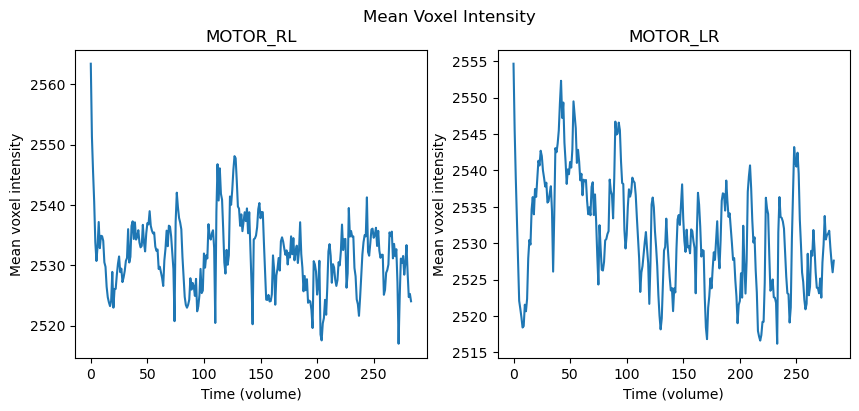

In [10]:
import matplotlib.pyplot as plt
import nibabel as nib
import os.path as op

mean_LR = nib.load(op.join(bids_root, 'sub-101410', 'func', 'sub-101410_task-motorLR_bold.nii')).get_fdata().mean(axis=(0,1,2))
mean_RL = nib.load(op.join(bids_root, 'sub-101410', 'func', 'sub-101410_task-motorRL_bold.nii')).get_fdata().mean(axis=(0,1,2))


fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Mean Voxel Intensity')

ax1.plot(mean_RL)
ax1.set_title('MOTOR_RL')
ax1.set(xlabel='Time (volume)', ylabel='Mean voxel intensity')

ax2.plot(mean_LR)
ax2.set_title('MOTOR_LR')
ax2.set(xlabel='Time (volume)', ylabel='Mean voxel intensity')

Because the first couple of volumes have an above average intensity, we will trim the number of volumes, i.e. remove the first two volumes of each run.

In [11]:
n_scan_run = nib.load(op.join(bids_root, 'sub-101410', 'func', 'sub-101410_task-motorLR_bold.nii')).shape[3]
n_scan_run

284

In [12]:
file_to_trim = glob.glob(op.join(bids_root, 'sub-101410', 'func', 'sub-101410_task-motorLR_bold.nii'))[0]
output_target = op.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motorLR_bold_settled.nii.gz')

# For this, knowing that there are originally 184 volumes and that you want to throw away the first 10, please fill in
# the following variables
start_vol = 2 # Where should we start? (First volume is 0, not 1 !)
number_of_volumes = n_scan_run - start_vol # How many volumes should we keep?   

# Function creating new nifti with trimmed number of volumes
fslroi(file_to_trim, output_target, str(start_vol), str(number_of_volumes))
print(f"You kept {nib.load(output_target).shape[-1]} volumes.")

You kept 282 volumes.


In [13]:
file_to_trim = glob.glob(op.join(bids_root, 'sub-101410', 'func', 'sub-101410_task-motorRL_bold.nii'))[0]
output_target = op.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motorRL_bold_settled.nii.gz')

# Function creating new nifti with trimmed number of volumes
fslroi(file_to_trim, output_target, str(start_vol), str(number_of_volumes))
print(f"You kept {nib.load(output_target).shape[-1]} volumes.")

You kept 282 volumes.


[Text(0.5, 0, 'Time (volume)'), Text(0, 0.5, 'Mean voxel intensity')]

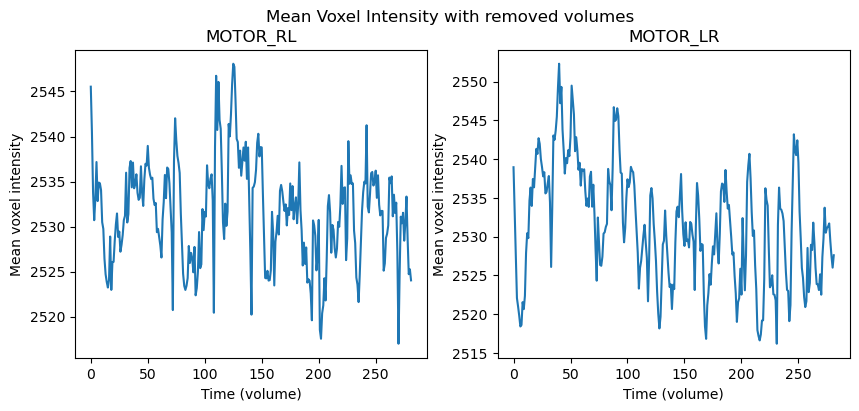

In [15]:
mean_LR_set = nib.load(op.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motorLR_bold_settled.nii.gz')).get_fdata().mean(axis=(0,1,2))
mean_RL_set = nib.load(op.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motorRL_bold_settled.nii.gz')).get_fdata().mean(axis=(0,1,2))


fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Mean Voxel Intensity with removed volumes')

ax1.plot(mean_RL_set)
ax1.set_title('MOTOR_RL')
ax1.set(xlabel='Time (volume)', ylabel='Mean voxel intensity')

ax2.plot(mean_LR_set)
ax2.set_title('MOTOR_LR')
ax2.set(xlabel='Time (volume)', ylabel='Mean voxel intensity')

ATTENTION: LE FICHIER SETTLED EST DANS LE PREPROC ROOT

Before merging both runs together, we want to rescale them. The reason is that different runs can have different overall signal intensities or variances, because of: scanner gain or baseline drift, physiological noise changes or small differences in acquisition or head position.

In [20]:
import os
import numpy as np
import nibabel as nib
from nilearn.image import concat_imgs, new_img_like
import matplotlib.pyplot as plt

# Raw fMRI runs
runs_info = [
    ('sub-101410_task-motorLR', 'sub-101410_task-motorLR_bold_settled.nii.gz'),
    ('sub-101410_task-motorRL', 'sub-101410_task-motorRL_bold_settled.nii.gz')
]

##### Pourquoi mettre un run name?

# Output folder for preprocessed/scaled runs
output_dir = os.path.join(preproc_root, 'sub-101410', 'func')
os.makedirs(output_dir, exist_ok=True)

concatenated = [] #merged file

# Process each run independently
for run_name, run_file in runs_info:
    run_path = os.path.join(preproc_root, 'sub-101410', 'func', run_file)  
    img = nib.load(run_path)
    data = img.get_fdata(dtype=np.float32)  # Use float32 to save memory
    
    # Simple brain mask
    brain_mask = data > 0    
    global_var = np.var(data[brain_mask], dtype=np.float64)
    
    # Rescale to unit variance
    scaled_data = data / np.sqrt(global_var)
    del data #free memory
    
    # Merge scaled run
    new_img = new_img_like(img, scaled_data)
    concatenated.append(new_img)# merging both runs
    del scaled_data #free memory


concat_img = concat_imgs(concatenated)
concat_img.to_filename(os.path.join(output_dir, 'sub-101410_task-motor_concat.nii.gz'))



In [ ]:
concat_path = os.path.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motor_concat.nii.gz')
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(concat_path)

Text(0, 0.5, 'Mean voxel intensity')

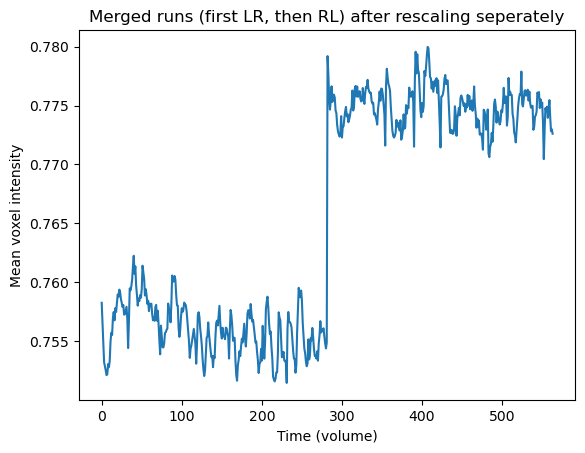

In [5]:
import matplotlib.pyplot as plt
import nibabel as nib
import os.path as op

mean_concat = nib.load(op.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motor_concat.nii.gz')).get_fdata().mean(axis=(0,1,2))

plt.plot(mean_concat)
plt.title('Merged runs (first LR, then RL) after rescaling seperately')
plt.xlabel('Time (volume)')
plt.ylabel('Mean voxel intensity')

In the mean voxel intensity plot above we can distinctly separate between the two runs (LR and RL). The jump betweeen them is roughly 0.03
#### WHY ????

## Motion correction

Attention: By default, MCFLIRT selects the middle volume of the EPI serie as reference to which other volumes are realigned.

In [ ]:
from fsl.wrappers import mcflirt

path_original_data = op.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motor_concat')
path_moco_data = os.path.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motor_concat_moco')
mcflirt(infile=path_original_data,o=path_moco_data, plots=True, report=True, dof=6, mats=True)

In [7]:
path_original_data = op.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motor_concat')
path_moco_data = os.path.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motor_concat_moco')
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(path_original_data)
fsleyesDisplay.load(path_moco_data)

By observing the translation plot, we can clearly see the big jump from run LR to run RL. This shows us, that the reference image chosen by MCFLIRT must be part of the first run (LR).

#### Framewise Displacement

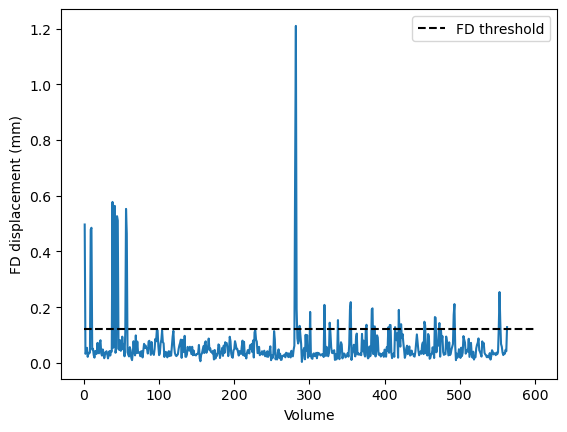

In [9]:
import matplotlib.pyplot as plt
import nibabel as nib
import os.path as op

def load_mot_params_fsl_6_dof(path):
    return pd.read_csv(path, sep='  ', header=None, 
            engine='python', names=['Rotation x', 'Rotation y', 'Rotation z','Translation x', 'Translation y', 'Translation z'])

mot_params = load_mot_params_fsl_6_dof(op.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motor_concat_moco.par'))

def compute_FD_power(mot_params):
    framewise_diff = mot_params.diff().iloc[1:]

    rot_params = framewise_diff[['Rotation x', 'Rotation y', 'Rotation z']]
    # Estimating displacement on a 50mm radius sphere
    # To know this one, we can remember the definition of the radian!
    # Indeed, let the radian be theta, the arc length be s and the radius be r.
    # Then theta = s / r
    # We want to determine here s, for a sphere of 50mm radius and knowing theta. Easy enough!
    
    # Another way to think about it is through the line integral along the circle.
    # Integrating from 0 to theta with radius 50 will give you, unsurprisingly, r0 theta.
    converted_rots = rot_params*50
    trans_params = framewise_diff[['Translation x', 'Translation y', 'Translation z']]
    fd = converted_rots.abs().sum(axis=1) + trans_params.abs().sum(axis=1)
    return fd

fd = compute_FD_power(mot_params).to_numpy()

threshold = np.quantile(fd,0.75) + 1.5*(np.quantile(fd,0.75) - np.quantile(fd,0.25))

#%matplotlib inline
plt.plot(list(range(1, fd.size+1)), fd)
plt.xlabel('Volume')
plt.ylabel('FD displacement (mm)')
plt.hlines(threshold, 0, 600,colors='black', linestyles='dashed', label='FD threshold')
plt.legend()
plt.show()

In [10]:
print(f"Indices of frames above threshold: {(np.where(fd > threshold)[0] + 1).tolist()}")

Indices of frames above threshold: [1, 9, 10, 38, 41, 44, 45, 56, 57, 281, 282, 283, 287, 301, 320, 327, 338, 354, 355, 376, 383, 384, 386, 387, 405, 407, 408, 414, 419, 422, 453, 454, 467, 468, 473, 492, 493, 552, 553, 554, 563]


## Gaussian smoothing

I am unsure on how to determine the size of our filter. Currently it is 6 mm

In [10]:
import subprocess
output_path = op.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motor_concat_moco')

cmd = 'fslmaths {} -s {} {}_smoothed-6mm'.format(output_path, 6/2.3548, output_path)
subprocess.run(['fslmaths',output_path, '-s', str(6/2.3548), '{}_smoothed-6mm'.format(output_path)])

CompletedProcess(args=['fslmaths', '/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/data/subject101410/derivatives/preprocessed_data/sub-101410/func/sub-101410_task-motor_concat_moco', '-s', '2.547987090198743', '/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/data/subject101410/derivatives/preprocessed_data/sub-101410/func/sub-101410_task-motor_concat_moco_smoothed-6mm'], returncode=0)

In [11]:
smoothed_path = op.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motor_concat_moco_smoothed-6mm')
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(output_path)
fsleyesDisplay.load(smoothed_path)

# 3. GLM Design Matrix

In [8]:
import pandas as pd
import numpy as np
import os.path as op

# Load event files
LRevents = pd.read_csv(op.join(bids_root, 'sub-101410', 'func', 'sub-101410_task-motorLR_events.tsv'), sep=",")
RLevents = pd.read_csv(op.join(bids_root, 'sub-101410', 'func', 'sub-101410_task-motorRL_events.tsv'), sep=",")

TR = 0.72
n_removed = 2
time_removed = TR * n_removed  # 1.44 s

def trim_first_volumes(events, time_removed):
    """Shorten the first event and shift everything so that onset >= 0."""
    events = events.copy()
    # 1️⃣ Shorten the first event by the removed time
    events.loc[0, 'duration'] = events.loc[0, 'duration'] - time_removed
    
    # 2️⃣ Shift *only* later events earlier by time_removed
    events.loc[1:, 'onset'] = events.loc[1:, 'onset'] - time_removed
    
    # 3️⃣ Keep the first onset exactly at 0
    events.loc[0, 'onset'] = 0.0
    return events

LRevents = trim_first_volumes(LRevents, time_removed)
RLevents = trim_first_volumes(RLevents, time_removed)

# 4️⃣ Concatenate with onset offset for the second run
offset_time = (LRevents['onset'] + LRevents['duration']).max()
RLevents['onset'] = RLevents['onset'] + offset_time
events_concat = pd.concat([LRevents, RLevents], ignore_index=True)

In [9]:
# Rename the colomn
events_concat = events_concat.rename(columns={'condition': 'trial_type'})
events_concat

,onset,duration,trial_type
0,0.00,6.56,NaN
1,6.56,3.00,cue
2,9.56,12.00,rh
3,21.56,3.00,cue
4,24.56,12.00,lf
5,36.56,3.00,cue
6,39.56,12.00,t
7,51.56,3.00,cue
8,54.56,12.00,rf
9,66.56,3.00,cue


In [10]:
from nilearn.glm.first_level import make_first_level_design_matrix, FirstLevelModel
import os.path as op

# Specify what sort of GLM we want (nature of the noise, repetition time of the data and other parameters)
fmri_glm = FirstLevelModel(t_r=0.72,
                           noise_model='ar1',
                           standardize=False,
                           hrf_model='spm', 
                           drift_model='polynomial',# adding drift model directly 
                           drift_order=3,
                          )

In [ ]:
# determining the number of scanns per run (the same for both runs)
n_scan_run = nib.load(op.join(preproc_root, 'sub-101410','func', 'sub-101410_task-motorRL_bold_settled.nii.gz')).shape[3]
run1_reg = np.zeros(2 * n_scan_run)
run2_reg = np.zeros(2 * n_scan_run)
run1_reg[:n_scan_run] = 1
run2_reg[n_scan_run:] = 1

reg_names = ['run1_LR_baseline', 'run2_RL_baseline']
extra_regs = [run1_reg, run2_reg]


import pandas as pd
confounds = pd.DataFrame(np.column_stack([run1_reg, run2_reg]),
                         columns=['run1_LR_baseline', 'run2_RL_baseline'])

fmri_concat_path = op.join(preproc_root, 'sub-101410','func', 'sub-101410_task-motor_concat.nii.gz')

# Fit the model to our design and data after adding 2 further regressors
fmri_glm = fmri_glm.fit(fmri_concat_path, events_concat, confounds)

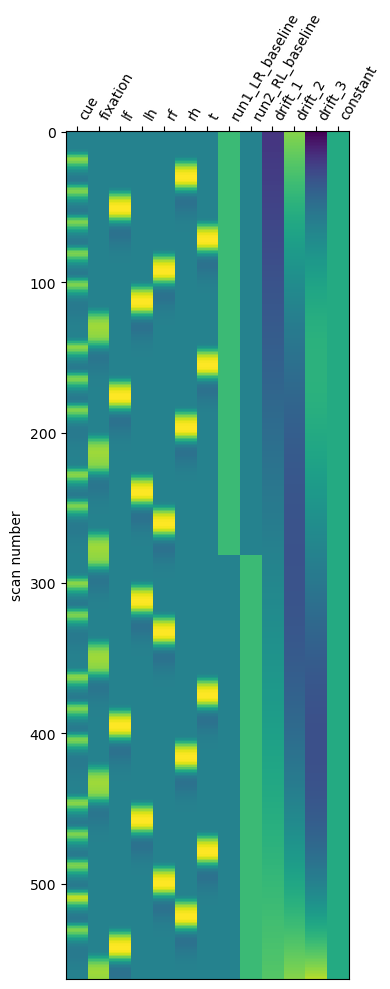

In [44]:
from nilearn.plotting import plot_design_matrix
import matplotlib.pyplot as plt

plot_design_matrix(fmri_glm.design_matrices_[0])
plt.show()

In [45]:
# Create the dictionary of the conditions

conditions = {
    'cue': np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 
    'fixation':np.array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
    'left_feet': np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
    'left_hand': np.array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
    'right_feet': np.array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]),
    'right_hand': np.array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]),
    'tongue': np.array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])
    
}

hand_minus_feet = conditions['left_hand'] + conditions['right_hand'] - conditions['left_feet'] - conditions['right_feet']


In [46]:
import nibabel as nib

z_map_hand_vs_feet = fmri_glm.compute_contrast(hand_minus_feet, output_type='z_score')

nib.save(z_map_hand_vs_feet, 'z_map_handVSfeet_uncorrected.nii.gz')

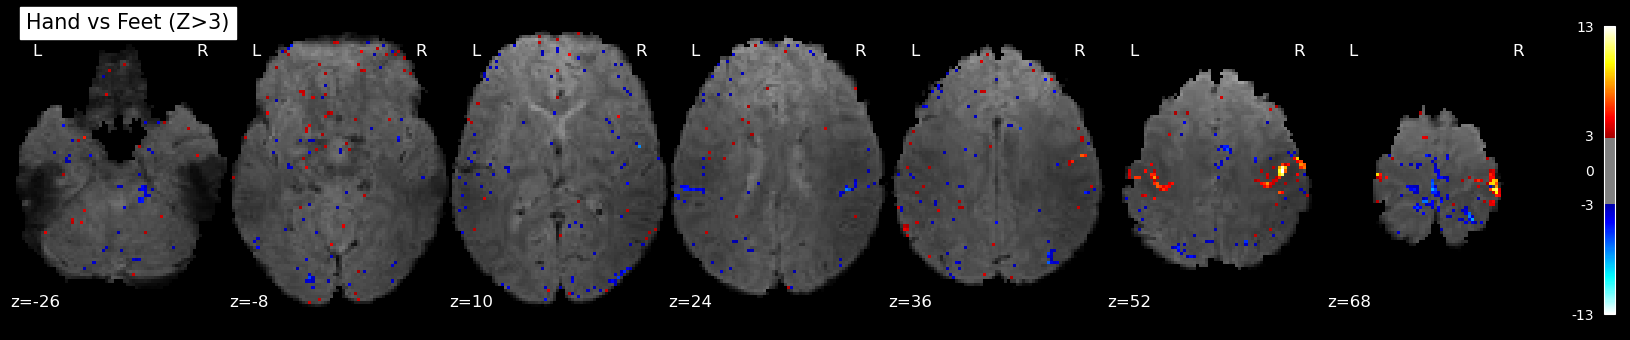

In [47]:
from nilearn.plotting import plot_stat_map
from nilearn.image import mean_img
from nilearn.plotting import find_cut_slices

coords = find_cut_slices(z_map_hand_vs_feet)

mean_img_ = mean_img(fmri_concat_path),
plot_stat_map(z_map_hand_vs_feet, bg_img=mean_img_[0], threshold=3.0,
              display_mode='z', cut_coords=coords, black_bg=True,
              title='Hand vs Feet (Z>3)')
plt.show()

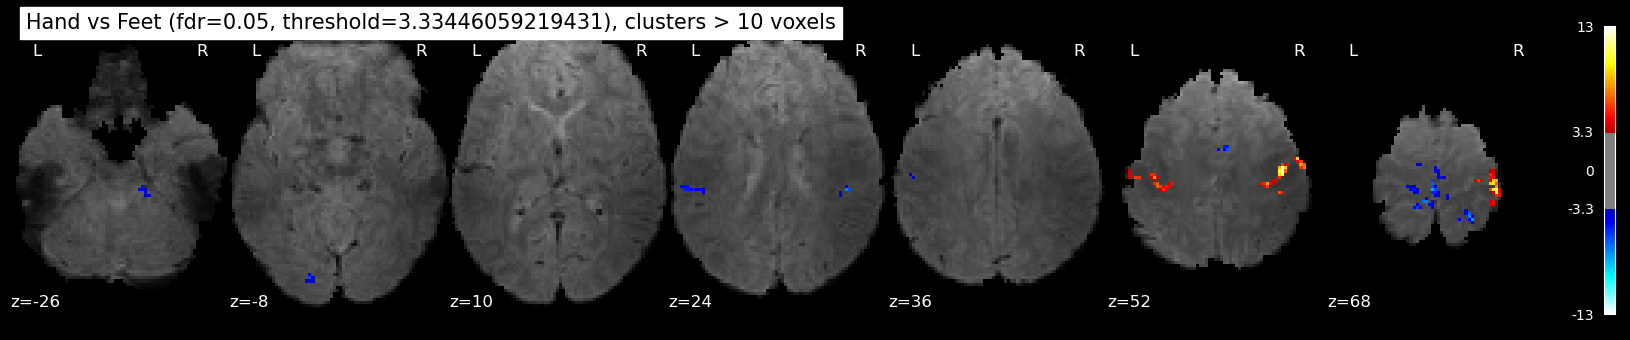

In [49]:
from nilearn.glm import threshold_stats_img

#Link to threshold_stats_img function documentation
#https://nilearn.github.io/dev/modules/generated/nilearn.glm.threshold_stats_img.html

cluster_size = 10 # Fill me with the number of voxels for a cluster to be kept
fdr_rate = 0.05 # Fill me with the fdr rate to use!

# Here, we apply the FDR correction + threshold
clean_map, threshold = threshold_stats_img(z_map_hand_vs_feet, alpha=fdr_rate, height_control='fdr', cluster_threshold=cluster_size)

# And this is just to plot here!
plot_stat_map(clean_map, bg_img=mean_img_[0], threshold=threshold,
              display_mode='z', cut_coords=coords, black_bg=True,
              title='Hand vs Feet (fdr={}, threshold={}), clusters > {} voxels'.format(fdr_rate, threshold, cluster_size))
plt.show()

#### AAL atlas parcellation

In [50]:
from nilearn import datasets, image

# Downlod the AAL atlas
aal = datasets.fetch_atlas_aal()
aal_img = image.load_img(aal['maps'])
aal_labels = aal['labels']
aal_data = aal_img.get_fdata()

##### Superimposing the contrast map onto the atlas

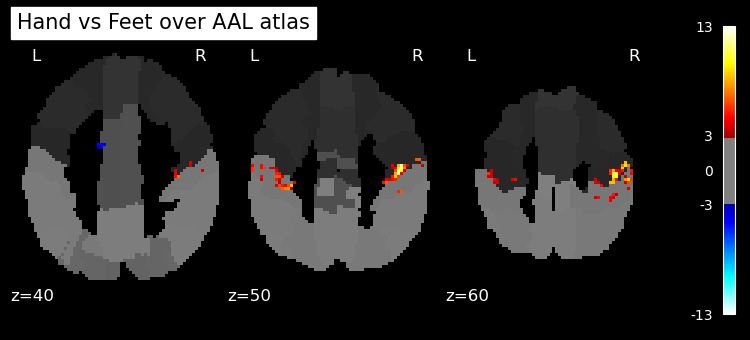

In [51]:
plot_stat_map(
    clean_map,
    bg_img=aal_img,
    threshold=3.0,
    display_mode='z',
    cut_coords=[40, 50, 60, 70],
    black_bg=True,
    title='Hand vs Feet over AAL atlas'
)
plt.show()



##### Find the name of the region with maximal contrast

In [52]:
from nilearn import datasets, image
import numpy as np

z_img = image.load_img(clean_map)
z_data = z_img.get_fdata()

# Find voxel with maximal contrast
max_idx = np.unravel_index(np.argmax(z_data), z_data.shape)
z_max = z_data[max_idx]
print("Z-max voxel:", max_idx)
print("Z max =", z_max)

# Identify the corresponding AAL region
region_id = str(int(aal_data[max_idx]))  ### ATTENTION, it has to be an int in a string

# Get the name of the AAL region
region_name = aal.labels[aal.indices.index(region_id)]
print(region_name)


Z-max voxel: (25, 51, 67)
Z max = 12.573736594747166
Precentral_R


ICA

Creation of data matrix X

In [5]:
import nibabel as nib
import numpy as np
import os
from nilearn.image import resample_img
from nilearn.input_data import NiftiMasker

# Initialize parameters
N_subj = 4  # adjusted because of memory issues
N_vol = 150  # adjusted because of memory issues
x, y, z = 91, 109, 91  # Spatial dimensions of each 3D volume (from your dataset shape)

# # Initialize the matrix X: (number of timepoints * number of subjects) x number of voxels
X = np.zeros((N_vol * N_subj, x * y * z), dtype=np.float32)  # Each row is a flattened 3D volume

n_nii = 0  # Counter to track which row to fill in X
nb_subj_counted = 0

# Loop over the directories where the data is stored
# data_path = op.join(preproc_root, 'sub-101410', 'func', 'sub-101410_task-motorRL_bold.nii.gz')
# data_path = '/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/fMRI/' 
data_path = op.join(preproc_root, 'sub-101410', 'func')
for root, dirs, files in sorted(os.walk(data_path)):
    if len(files) != 0:
        nb_subj_counted += 1
        if nb_subj_counted > N_subj:  # Stop after processing N_subj subjects
            
            print(f"Loading subject {nb_subj_counted}")

    for file in sorted(files):
        if file.endswith('.nii'):
            # Load the 4D fMRI data
            img = nib.load(os.path.join(root, file))

            # Check the shape of the image (it should be 4D: [x, y, z, timepoints])
            print(f"Shape of {file}: {img.shape}")

            # Flatten each volume (3D) and store it in X
            for t in range(N_vol):  # Iterate over each timepoint
                X[n_nii, :] = img.get_fdata()[:, :, :, t].flatten()
                n_nii += 1

# Ensure the data has been correctly loaded and flattened
print(f"Shape of X after loading and flattening: {X.shape}")

# Normalize the data (z-score normalization) across subjects
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Replace NaN values with zeros (if any)
X = np.nan_to_num(X, 0)

print("Data preprocessing complete.")

Shape of X after loading and flattening: (600, 902629)
Data preprocessing complete.


In [10]:
#test for debug
img = nib.load(data_path)
print(f"Shape of {file}: {img.shape}")


FileNotFoundError: No such file or no access: '/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/data/subject101410/derivatives/preprocessed_data/sub-101410/func/sub-101410_task-motorRL_bold.nii.gz'

Apply ICA

In [15]:
# Number of components for ICA (You can experiment with different values, e.g., [4, 10, 20, etc.])
from sklearn.decomposition import PCA
from sklearn.decomposition import FastICA
import numpy as np

nb_components = [4]  # other values possible but first 4 chosen because they usually capture the most variance or meaningful patterns.

S_dict = {}  # Store the sources for different numbers of components

# Check if there are NaN or Inf values before applying PCA or ICA
def check_and_clean_data(data):
    """Check and clean NaN or Inf values in the dataset."""
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
        print("Warning: NaN or Inf values detected in the data. Cleaning...")
        # Replace NaNs and Infs with zeros
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    return data

# Clean the data before applying PCA or ICA
X_cleaned = check_and_clean_data(X)

# Now proceed with PCA and ICA
for n in nb_components:
    print(f"Processing {n} components")
    
    # Step 1: Apply PCA (preprocessing for ICA)
    pca = PCA(n_components=n)  # Use fewer components for PCA (just n components)
    try:
        X_pca = pca.fit_transform(X_cleaned)  # Reduce dimensionality to the first n principal components
        print("PCA transformation successful. Shape of PCA result:", X_pca.shape)
        
        # Debugging: Print the variance explained by each component
        print(f"Explained variance ratio by PCA components: {pca.explained_variance_ratio_}")
        
    except ValueError as e:
        print(f"Error during PCA: {e}")
        continue  # Skip to next component if there's a problem with PCA

    # Explicitly check for NaN or Inf after PCA
    X_pca = check_and_clean_data(X_pca)
    
    # Check if PCA has caused issues with variance (e.g., constant values)
    if np.all(np.var(X_pca, axis=0) == 0):
        print("Warning: After PCA, all components have zero variance. Skipping ICA for this configuration.")
        continue
    
    # Step 2: Run FastICA
    ica = FastICA(n_components=n, random_state=1, max_iter=200)
    try:
        S_ = ica.fit_transform(X_pca)  # S_ contains the estimated sources
        print(f"ICA completed successfully for {n} components. Shape of ICA sources:", S_.shape)
    except ValueError as e:
        print(f"Error during ICA: {e}")
        continue  # Skip to next component if there's a problem with ICA
    
    # Store the sources for later use
    S_dict[n] = S_
    
    print(f"Finished processing {n} components.")

print(f"Keys in S_dict: {S_dict.keys()}")  # This will show the available component numbers


Processing 4 components
PCA transformation successful. Shape of PCA result: (600, 4)
Explained variance ratio by PCA components: [nan nan nan nan]
Keys in S_dict: dict_keys([])


/opt/conda/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:794: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var


Visualize the Independent Components (axial view only)

In [ ]:
# Initialize the dictionary to store ICA results
S_dict = {}

# List of the number of components you want to use for ICA (e.g., [4, 10, 20])
nb_components = [4, 10, 20]  # Example values, adjust as needed

# Loop through each component number in nb_components and apply ICA
for n in nb_components:
    print(f'Running ICA with {n} components...')
    
    # Run ICA (assuming you're using FastICA or CanICA)
    ica = FastICA(n_components=n, random_state=1, max_iter=200)  # You can also use CanICA if desired
    S_ = ica.fit_transform(X.T)  # X should be your preprocessed fMRI data (voxels x time)
    
    # Store the ICA results in the dictionary
    S_dict[n] = S_  # Store the sources (S) for the current number of components
    print(f"Stored ICA results for {n} components.")

# Now, after ICA is applied, you can access the results using S_dict[n]
print(f"Keys in S_dict: {S_dict.keys()}")  # This will show the available component numbers


Running ICA with 4 components...


In [18]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn.plotting import plot_stat_map
from nilearn.input_data import NiftiMasker
from nilearn import image, plotting

t1w_img_path = '/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/data/subject101410/derivatives/preprocessed_data/sub-101410/anat/sub-101410_T1w.nii.gz'

# Load the T1-weighted image
t1w_img = nib.load(t1w_img_path)

print(S_dict.keys())  # This will show you the available keys in the dictionary
nb_components = [4, 10, 20]  # Example values, adjust as needed

for n in nb_components:
    print(f'Number of components: {n}')
    
    # Get the estimated sources for the current number of components
    S_ = S_dict[n].copy()
    
    # Loop over the first few components (up to 4)
    for idx, s in enumerate(S_.T[:min(4, S_.T.shape[0])]):  # Plot up to 4 components
        # Reshape the component (s) into a 3D volume shape (x, y, z)
        s_img = nib.Nifti1Image(np.reshape(s, (x, y, z)), affine)
        
        # If you have a brain mask, apply it. Otherwise, use the brain mask from the T1-weighted image
        # Create a mask from the T1 image
        masker = NiftiMasker(mask_img=T1w_img)
        data = masker.fit_transform(s_img)
        masked_ = masker.inverse_transform(data)  # Apply the mask
        
        # Plot the ICA component overlaid on the T1-weighted image in axial view
        plot_stat_map(masked_, display_mode="ortho", title=f'Component {idx + 1}', 
                      colorbar=True, black_bg=True, threshold=2 * np.std(s), bg_img=T1w_img)
        plt.show()


dict_keys([])
Number of components: 4


KeyError: 4

### Neuer Versuch ICA

In [6]:
import nibabel as nib
import numpy as np
import os
from nilearn.image import resample_img
from nilearn.input_data import NiftiMasker

# Initialize parameters
N_subj = 4  # adjusted because of memory issues
N_vol = 150  # adjusted because of memory issues
x, y, z = 91, 109, 91  # Spatial dimensions of each 3D volume (from your dataset shape)

# Initialize the matrix X: (number of timepoints * number of subjects) x number of voxels
X = np.zeros((N_vol * N_subj, x * y * z), dtype=np.float32)  # Each row is a flattened 3D volume

n_nii = 0  # Counter to track which row to fill in X
nb_subj_counted = 0

# Loop over the directories where the data is stored
data_path = '/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/fMRI/' 
# data_path = op.join(preproc_root, 'sub-101410', 'func')
for root, dirs, files in sorted(os.walk(data_path)):
    if len(files) != 0:
        nb_subj_counted += 1
        if nb_subj_counted > N_subj:  # Stop after processing N_subj subjects
            break
        print(f"Loading subject {nb_subj_counted}")

    for file in sorted(files):
        if file.endswith('.nii'):
            # Load the 4D fMRI data
            img = nib.load(os.path.join(root, file))

            # Check the shape of the image (it should be 4D: [x, y, z, timepoints])
            print(f"Shape of {file}: {img.shape}")

            # Flatten each volume (3D) and store it in X
            for t in range(N_vol):  # Iterate over each timepoint
                X[n_nii, :] = img.get_fdata()[:, :, :, t].flatten()
                n_nii += 1

# Ensure the data has been correctly loaded and flattened
print(f"Shape of X after loading and flattening: {X.shape}")

# Normalize the data (z-score normalization) across subjects
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Replace NaN values with zeros (if any)
X = np.nan_to_num(X, 0)

print("Data preprocessing complete.")

Loading subject 1
Shape of tfMRI_MOTOR_LR.nii: (91, 109, 91, 284)
Shape of tfMRI_MOTOR_RL.nii: (91, 109, 91, 284)
Loading subject 2
Loading subject 3
Shape of X after loading and flattening: (600, 902629)
Data preprocessing complete.


In [7]:
import nibabel as nib
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA
from nilearn.input_data import NiftiMasker
from nilearn.plotting import plot_stat_map
import matplotlib.pyplot as plt

# Parameters
N_subj = 4
N_vol = 150
x, y, z = 91, 109, 91

# data_path = '/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/data/subject101410/fMRI/'
X = np.zeros((N_vol * N_subj, x * y * z), dtype=np.float32)
n_nii = 0
nb_subj_counted = 0

for root, dirs, files in sorted(os.walk(data_path)):
    if len(files) != 0:
        nb_subj_counted += 1
        if nb_subj_counted > N_subj:
            break

    for file in sorted(files):
        if file.endswith('.nii'):
            img = nib.load(os.path.join(root, file))
            for t in range(N_vol):
                X[n_nii, :] = img.get_fdata()[:, :, :, t].flatten()
                n_nii += 1


In [8]:
# Normalization
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = np.nan_to_num(X, 0)

# ICA
nb_components = [4]
S_dict = {}

for n in nb_components:
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X)
    X_pca = np.nan_to_num(X_pca, 0)

    ica = FastICA(n_components=n, random_state=1, max_iter=200)
    S_ = ica.fit_transform(X_pca)
    S_dict[n] = S_

In [34]:
# Visualization
# T1w_img = nib.load('/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/data/sub-101410/anat/sub-101410_T1w.nii.gz')
T1w_img = nib.load('/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/data/subject101410/derivatives/preprocessed_data/sub-101410/anat/sub-101410_T1w.nii.gz')

for n in nb_components:
    S_ = S_dict[n].copy()
    for idx, s in enumerate(S_.T[:min(4, S_.T.shape[0])]):
        s_img = nib.Nifti1Image(np.reshape(s, (x, y, z)), T1w_img.affine)
        masker = NiftiMasker(mask_img=T1w_img)
        data = masker.fit_transform(s_img)
        masked_ = masker.inverse_transform(data)
        plot_stat_map(masked_, display_mode="ortho", title=f'Component {idx + 1}',
                      colorbar=True, black_bg=True, threshold=2 * np.std(s), bg_img=T1w_img)
        plt.show()

ValueError: cannot reshape array of size 600 into shape (91,109,91)

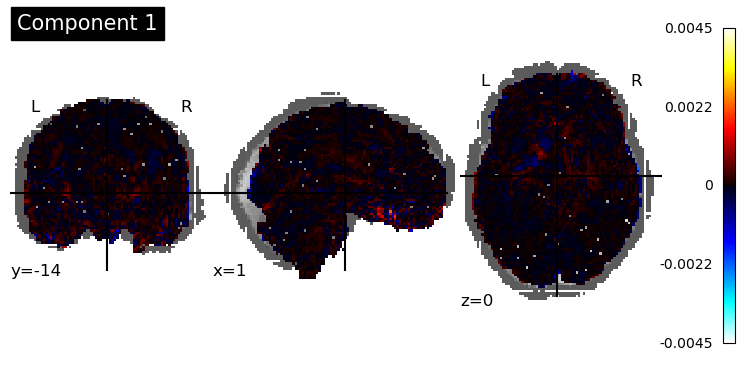

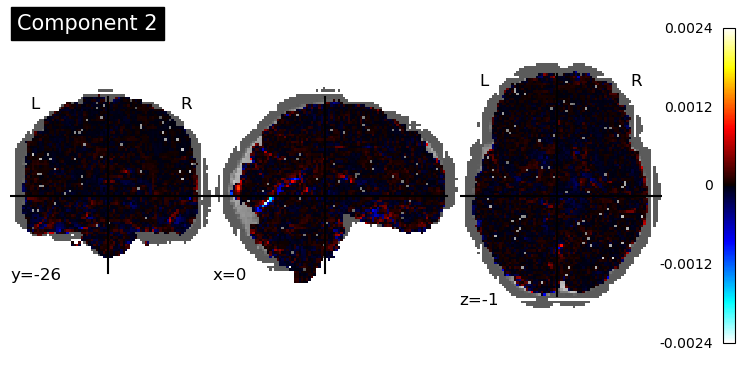

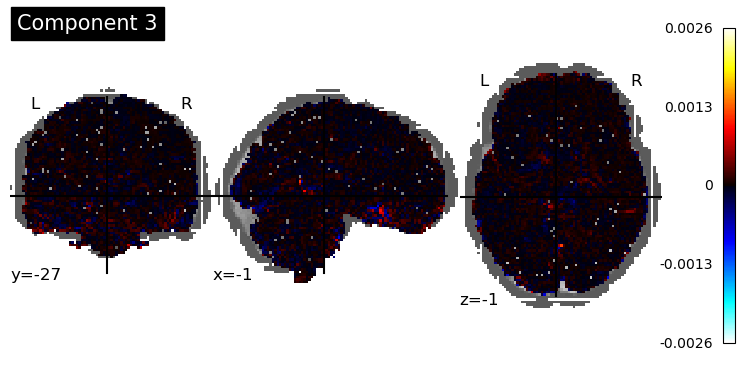

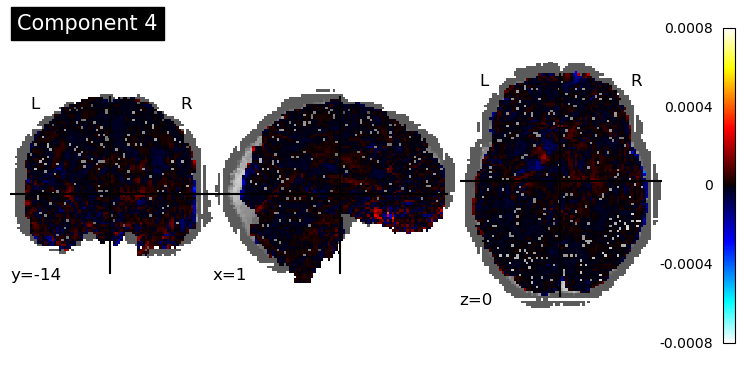

In [23]:
# assumes you already built X with shape (n_samples, n_voxels),
# fit PCA -> pca, fit ICA on X_pca -> ica, and you know (x, y, z)

# (optional) load one functional image to grab the correct affine/shape
# Use any of the functional files you loaded earlier:
func_example_path = next(
    os.path.join(root, f) for root,_,files in os.walk(data_path)
    for f in files if f.endswith(('.nii', '.nii.gz'))
)
func_img = nib.load(func_example_path)
func_affine = func_img.affine
func_shape = func_img.shape[:3]  # should be (91,109,91) in your dataset

# 1) back-project ICA components from PCA space to voxel space
#    shapes: ica.components_ -> (n, n); pca.components_ -> (n, n_voxels)
spatial_maps_vox = ica.components_ @ pca.components_   # (n, n_voxels)

# 2) turn each component into a NIfTI image in functional space
n = spatial_maps_vox.shape[0]
for idx in range(min(4, n)):
    comp_flat = spatial_maps_vox[idx]                  # (n_voxels,)
    comp_vol = comp_flat.reshape(func_shape)           # (x,y,z)
    comp_img = nib.Nifti1Image(comp_vol, func_affine)

    # (optional) resample background T1 to functional space for clean overlay
    from nilearn.image import resample_to_img
    bg_img = resample_to_img(T1w_img, func_img, interpolation='continuous')

    from nilearn.plotting import plot_stat_map
    plot_stat_map(
        comp_img,
        bg_img=bg_img,
        display_mode="ortho",
        title=f"Component {idx+1}",
        colorbar=True,
        black_bg=False
    )
    plt.show()




### Copy from lab 7

In [40]:
# Prepare data
from tqdm.notebook import trange, tqdm

path_func_img = '/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/fMRI/tfMRI_MOTOR_LR.nii'
img_ex = nib.load(path_func_img)

# Get affine transform -- check nibabel library for more info!
affine = nib.load(path_func_img).affine
x,y,z = img_ex.shape[:]

N_vol=200
N_subj=8 ## NOTE: You can increase or decrease the number of subjects
N_tot=N_vol*N_subj

#* Initialize X
X = np.zeros((N_tot,x*y*z)) # total_timepoints(15subj*200timepoints) x voxel_num
i = 0
n_nii  = 0
nb_subj_counted=0
for root, dirs, files in sorted(os.walk('/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/fMRI/')):
    if len(files)!= 0:
        nb_subj_counted=nb_subj_counted+1
        if nb_subj_counted > N_subj:
            break
        print(f"Loading subject {nb_subj_counted}")
    for j in trange(len(files)):
        file = sorted(files)[j]
        if file.endswith('.nii'):
            if nb_subj_counted<N_subj+1:
                X[n_nii,:] = nib.load(root+'/'+file).get_fdata().flatten()
                n_nii+=1

X = zscore(X, axis = 1) # across subjects
X = np.nan_to_num(X,0) # nan to 0s
print("X matrix size: ", X.shape)

ValueError: too many values to unpack (expected 3)

In [ ]:
import os, nibabel as nib, numpy as np
from scipy.stats import zscore

# Settings
data_root = '/home/jovyan/data/NeuralSignalsANDSignalProcessing/NSSPMini_Project1/fMRI/'
N_subj = 8
N_vol  = 200  # we’ll take the first 200 volumes per subject

# Find 4D nifti files (accept .nii and .nii.gz)
four_d_files = []
for root, _, files in os.walk(data_root):
    for f in files:
        if f.endswith(('.nii', '.nii.gz')):
            four_d_files.append(os.path.join(root, f))
four_d_files = sorted(four_d_files)[:N_subj]
if not four_d_files:
    raise RuntimeError("No NIfTI files found.")

# Inspect one file to get spatial dims
img_ex = nib.load(four_d_files[0])
x, y, z = img_ex.shape[:3]

# Build X by stacking timepoints across subjects
X_rows = []
for si, fpath in enumerate(four_d_files, 1):
    img = nib.load(fpath)
    data = img.get_fdata()  # (x,y,z,t)
    if data.ndim != 4:
        raise ValueError(f"{fpath} is not 4D.")
    t = min(N_vol, data.shape[3])
    # take first t volumes, reshape to (t, voxels)
    X_rows.append(data[:, :, :, :t].reshape(-1, t).T)
    print(f"Loaded subject {si}: using {t} volumes -> rows now {sum(r.shape[0] for r in X_rows)}")

X = np.vstack(X_rows)              # shape = (N_subj*N_vol, x*y*z)
X = zscore(X, axis=0, nan_policy='omit')  # standardize per voxel across time/subjects
X = np.nan_to_num(X, 0)

print("X matrix size:", X.shape)   # expected: (N_subj*N_vol, x*y*z)


Loaded subject 1: using 200 volumes -> rows now 200
Loaded subject 2: using 200 volumes -> rows now 400


In [36]:
print(img_ex)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (91, 109, 91, 284)
affine:
[[  -2.    0.    0.   90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  4  91 109  91 284   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.    2.    2.    2.    0.72  0.    0.    0.  ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'FSL5.0'
aux_file        : b''
qform_code  

In [ ]:
#* Build brain mask to restrict analysis within the brain
icbms = datasets.fetch_icbm152_2009()
masker = NiftiMasker(mask_img=icbms.mask)
plot_stat_map(icbms.mask, black_bg=True, title='the brain mask', colorbar=False,)

In [ ]:
#* Run FastICA on X -- check 

S_dict = {}

# assign the variable nb_components to be the list of components (try 3-5 values )

nb_components =  [4,]#10]#20, 60 ...]

## NOTE that 60 components can be computational costly

#* We will transpose the matrix X so that ICA algorithm operates on the voxels dimension.
#* In other words, the estimated sources (S) should be have dimensionality [#voxels]

for n in nb_components:
    print(f"Processing component {n}")
    # run PCA as a preprocessing step for ICA with twice the number of components
    n2=2*n
    ### YOUR CODE HERE
    pca = PCA(n_components=n2)
    H = pca.fit_transform(X.T)  # Reconstruct signals based on orthogonal components
    
    # Reminder: Fast ICA model S = X W
    print("Running FastICA with n = %d components" %n)

    ica = FastICA(n_components=n, random_state=1, max_iter=200)
    S_ = ica.fit_transform(H)  # Get the estimated sources (S)

    print(S_.shape)
    W_ = ica.components_ # Get the estimated un-mixing matrix (W) -- will not be used further on
    S_dict[n] = S_ # store the results in a dictionary

    print("Done")

In [ ]:
print("The shape of the estimated Sources is: {}".format(S_.shape))

In [ ]:
#* Read T1-weighted template
T1w_img = nib.load(op.join(data_path, 'PLS_data/T1w_restore_brain.nii'))

In [ ]:
#* Plot the group-level independent components for the different number of requested components.
## Here you can use only 3 components to reduce the plots
## e.g. uncomment this if you used more than 3 values before
# nb_components = nb_components[:3]

for n in nb_components:
    print('Number of components: ',n)
    S_ = S_dict[n].copy()
    for idx, s in enumerate(S_.T[:min(4, S_.T.shape[0]),:]): # plot min(4, #comp_estimated) components , change 10 with 4 to plot less
        s_img = nib.Nifti1Image(np.reshape(s, (x,y,z)), affine)
        data = masker.fit_transform(s_img)
        masked_ = masker.inverse_transform(data) # mask the components
        plot_stat_map(masked_, display_mode="z", title='Case of {} estimated components: comp #{}'.format(n,idx+1),
                      colorbar=True, black_bg=True, threshold=2*np.std(s), bg_img=T1w_img,)
                      #output_file=save_results + "ICA_components_{}_n_{}.png".format(idx,n)) # uncomment to save plot
        plt.show()